Regression - ML algo + continous numerical values

EX =Sal, house price, temp, sales

classification - categories

EX - Student passed

SLR - One dependent variable using one indipendent var

SLR -One dependent variable using one independent variable

hours study marks

2 40

3 50

4 60

5 70

Relationship btw hours and marks

Independent var - Hours

Dependent var - Marks

y = mx+c

y = predicted o/p

x = Input

m Slope

c = Intercept

EX - marks

marks = 10 * 5+20 = 70

In [916]:
import pandas as pd # data handling 

import numpy as np # numerical calculation 

import matplotlib.pyplot as plt # visual graph plot 

from sklearn.model_selection import train_test_split # Random suffle, split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score # Evaluate 

from sklearn.datasets import load_diabetes
diabetes=load_diabetes()

In [917]:
print(type(diabetes))

<class 'sklearn.utils._bunch.Bunch'>


In [918]:
print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [919]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [920]:
print(diabetes.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [921]:
df = pd.DataFrame(
    diabetes.data,
    columns= diabetes.feature_names
)

In [922]:
df['target']= diabetes.target

In [923]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [924]:
df.tail()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
441,-0.045472,-0.044642,-0.073030,-0.081413,0.083740,0.027809,0.173816,-0.039493,-0.004222,0.003064,57.0


In [925]:
print("Row:", df.shape[0])

Row: 442


In [926]:
print("columns:", df.shape[1])

columns: 11


In [927]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [928]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [929]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [930]:
df.isnull().sum() # count null values 

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [931]:
df.duplicated().sum() # dupt


np.int64(0)

In [932]:
from sklearn.datasets import load_diabetes
import pandas as pd

diabetes = load_diabetes()

df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target

In [933]:
X = df[["bmi"]]
Y = df["target"]

In [934]:
print(X.head())
print(Y.head())

        bmi
0  0.061696
1 -0.051474
2  0.044451
3 -0.011595
4 -0.036385
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64


In [935]:
print(df.columns.tolist())

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


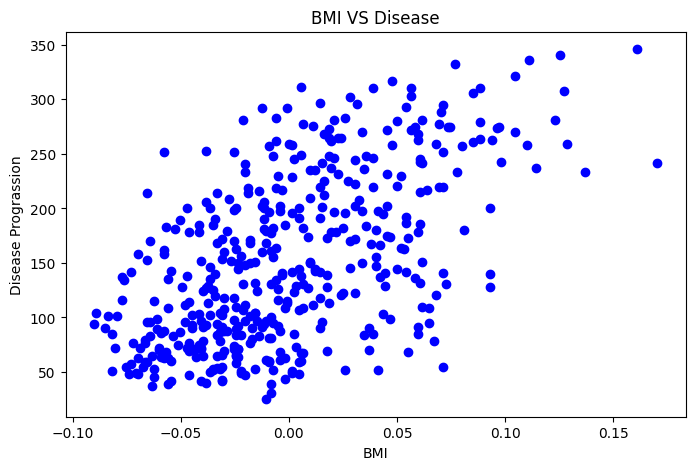

In [936]:
plt.figure(figsize=(8,5))
plt.scatter(X,Y,color='blue')
plt.xlabel("BMI")
plt.ylabel("Disease Prograssion")
plt.title("BMI VS Disease")
plt.show()

In [937]:
from sklearn.model_selection import train_test_split

In [938]:
# X_train, X_test, Y_train, Y_test = train_test_split(
#     X,Y,test_size=0.2,
#     random_state = 42
# )

In [939]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [940]:
len(X_train)

353

In [941]:
len(X_test)

89

In [942]:
model = LinearRegression()

In [943]:
model.fit(X_train, Y_train) #train

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [944]:
y_pred = model.predict(X_test)

In [945]:
comparison = pd.DataFrame({
    "Actual":Y_test.values,
    "Predicted": y_pred
})
comparison.head(20)

,Actual,Predicted
0,219.0,145.806227
1,70.0,188.857390
2,202.0,147.958785
3,230.0,203.925298
4,111.0,131.814599
5,84.0,127.509482
6,242.0,322.315998
7,272.0,197.467623
8,94.0,61.856458
9,96.0,167.331809


In [946]:
mae = mean_absolute_error(Y_test,y_pred) # it tells the average mistake 
mse = mean_squared_error(Y_test,y_pred) # errors more then panalty high 

In [947]:
r2 = r2_score(Y_test,y_pred) # accurate

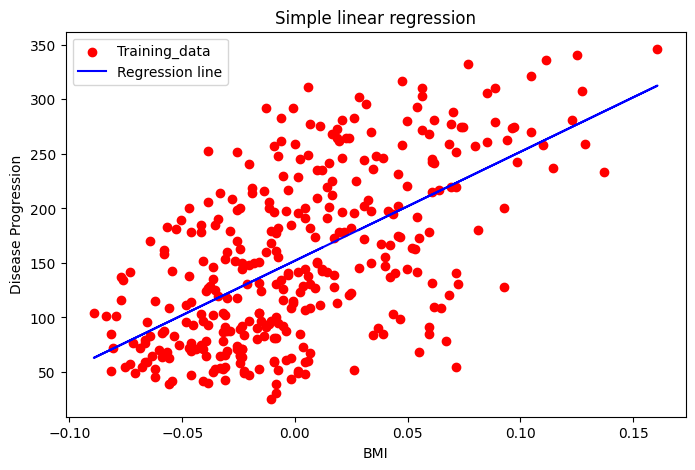

In [948]:
plt.figure(figsize=(8,5))
plt.scatter(X_train,Y_train,color = "red", label="Training_data")
plt.plot(X_train, model.predict(X_train), color = "blue", label="Regression line")

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple linear regression")
plt.legend()
plt.show()

In [949]:
new_b = [[0.04]]
prediction = model.predict(new_b)
print(prediction)

[191.94646178]


c:\Users\MAYUR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Hours vs Marks data (markdown cell)
# Hours    marks
# 1        30
# 2        40
# 3        45
# 4        55
# 5        65
# 6        72
# 7        80

In [950]:
# Step 1 - Imports
train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [951]:
# Step 2 - Create Dataset
data = {
    "Hours": [1, 2, 3, 4, 5, 6, 7],
    "Marks": [30, 40, 45, 55, 65, 72, 80]
}
df = pd.DataFrame(data)
print(df.head())

   Hours  Marks
0      1     30
1      2     40
2      3     45
3      4     55
4      5     65


In [952]:
# Step 3 - Check duplicates & columns
print(df.duplicated().sum())
print(df.columns)

0
Index(['Hours', 'Marks'], dtype='object')


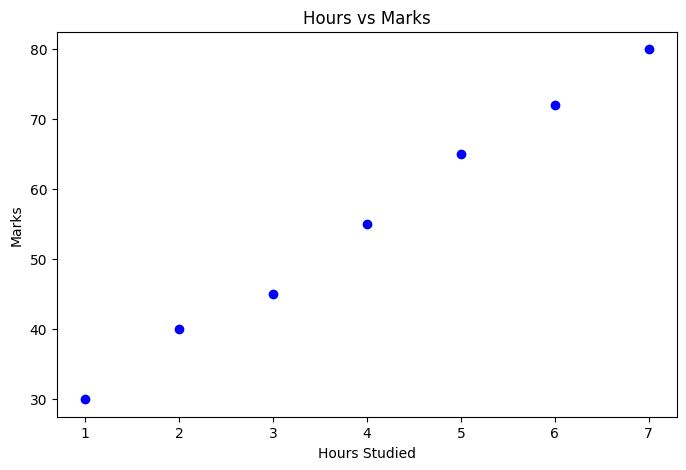

In [953]:
# Step 4 - Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(df["Hours"], df["Marks"], color="blue")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours vs Marks")
plt.show()

In [954]:
# Step 5 - Select X and y
X = df[["Hours"]]
y = df["Marks"]
print(X.head())
print(y.head())

   Hours
0      1
1      2
2      3
3      4
4      5
0    30
1    40
2    45
3    55
4    65
Name: Marks, dtype: int64


In [955]:
# Step 6 - Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [956]:
# Step 7 - Train model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [957]:
# Step 8 - Predict
y_pred = model.predict(X_test)

# Compare actual vs predicted
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
print(comparison)

   Actual  Predicted
0      30       28.6
1      40       37.3


In [958]:
# Step 9 - Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 :", r2)

MAE: 2.0500000000000025
MSE: 4.625000000000011
R2 : 0.8149999999999996


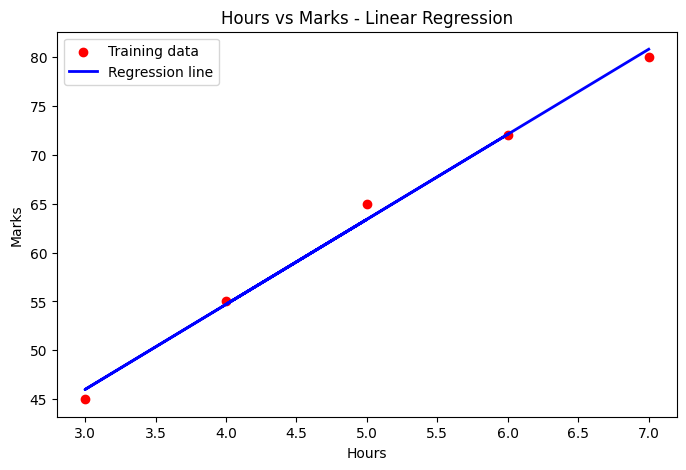

In [959]:
# Step 10 - Plot regression line
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color="red", label="Training data")
plt.plot(X_train, model.predict(X_train), color="blue",
         label="Regression line", linewidth=2)
plt.legend()
plt.xlabel("Hours")
plt.ylabel("Marks")
plt.title("Hours vs Marks - Linear Regression")
plt.show()

In [960]:
# Step 11 - Predict for new value
new_hours = [[6]]
prediction = model.predict(new_hours)
print("Predicted Marks:", prediction)

Predicted Marks: [72.1]


c:\Users\MAYUR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [961]:
#Multiple Linear Regression 
#when one output depends on multiple input variable ,we use MLR

In [962]:
#ex- House predictions,students marks

In [963]:
#Single LR - y = mx+c

In [964]:
#Multi LR - y= b0+b1x1+b2x2....b2xn

In [965]:
#why?#because it has multiple independent variable.

In [966]:
#y = output
#b0=intercept
#b1b2b3... = coefficient
# x1,x2,x3... = features

Practicle

In [967]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

In [968]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [969]:
df.head(20)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [970]:
housing = fetch_california_housing()

In [971]:
print(type(housing))

<class 'sklearn.utils._bunch.Bunch'>


In [972]:
print(housing.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [973]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [974]:
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

In [975]:
df["HousePrice"] = housing.target

In [976]:
df.head(20)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [977]:
df.tail(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [978]:
print(df.shape)

(20640, 9)


In [979]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [980]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [981]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

In [982]:
df.duplicated().sum()

np.int64(0)

In [983]:
corr=df.corr()

In [984]:
corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
HousePrice,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [985]:
corr['HousePrice'].sort_values(ascending=False)

HousePrice    1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: HousePrice, dtype: float64

In [986]:
x = df.drop("HousePrice",axis=1)

In [987]:
y = df['HousePrice']

In [988]:
print(x.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


In [989]:
print(y.head())

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HousePrice, dtype: float64


In [990]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=40
)

In [991]:
print(x_train.shape)

(16512, 8)


In [992]:
print(x_test.shape)

(4128, 8)


In [993]:
print(y_test.shape)

(4128,)


In [994]:
model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [995]:
print(model.intercept_)

-36.84337456381572


In [996]:
y_pred = model.predict(x_test)

In [997]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predict': y_pred
})
comparison.head(15)

,Actual,Predict
0,2.26500,2.004130
1,1.96200,2.575619
2,1.45800,1.197698
3,4.20000,1.689343
4,2.57800,2.187609
5,1.44100,2.138624
6,3.47400,2.820414
7,1.85400,1.626702
8,4.32100,3.145142
9,2.88200,3.016335


In [998]:
mae = mean_absolute_error(y_test, y_pred)

In [999]:
mae

0.5389572480554758

In [1000]:
mse = mean_squared_error(y_test, y_pred)

In [1001]:
mse

0.5417517275769406

In [1002]:
r2 = r2_score(y_test, y_pred)

In [1003]:
r2

0.6075794091011186

In [1004]:
new_house =[[
    8,20,6.5,1,1000,3.0,34.2,-118.4
]]
prediction_new_house = model.predict(new_house)
prediction_new_house[0]

c:\Users\MAYUR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(3.6951677644476177)

In [1005]:
residuals = y_test-y_pred
residuals

6607     0.260870
884     -0.613619
9457     0.260302
18681    2.510657
4654     0.390391
           ...   
19314   -0.721410
15433   -0.186461
3631    -0.609609
3689     0.101141
11895   -0.535655
Name: HousePrice, Length: 4128, dtype: float64

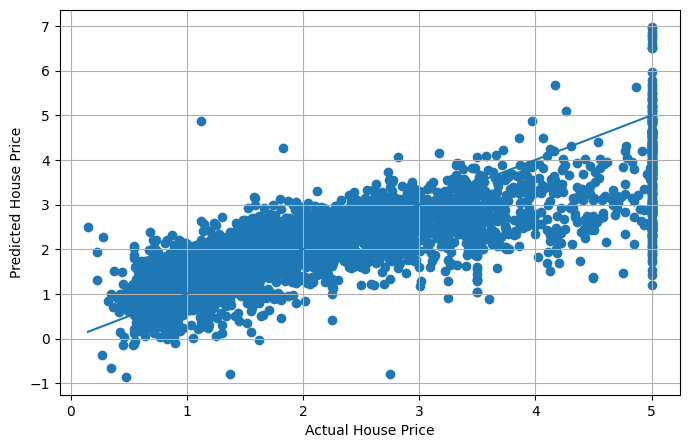

In [1006]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.grid(True)
plt.show()

In [1007]:

#data:
#Experience                                 Education                skills        salary
 #1                                             12                    2             25000
 #2                                             12                    3             30000
 #3                                             15                    4             38000
 #4                                             16                    5             47000
 #5                                             18                    6             60000
 #6                                             18                    7             70000

In [1008]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [1009]:
# Data
data = {
    'Experience': [1, 2, 3, 4, 5, 6],
    'Education':  [12, 12, 15, 16, 18, 18],
    'Skills':     [2, 3, 4, 5, 6, 7],
    'Salary':     [25000, 30000, 38000, 47000, 60000, 70000]
}

df = pd.DataFrame(data)

In [1010]:
# Features & Target
x = df.drop('Salary', axis=1)
y = df['Salary']

In [1011]:
# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=40
)

In [1012]:
# Model
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1013]:
# Predict
y_pred = model.predict(x_test)

In [1014]:
# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

In [1015]:
print("Intercept :", model.intercept_)
print("MAE       :", mae)
print("MSE       :", mse)
print("R2 Score  :", r2)

Intercept : -43249.999999999985
MAE       : 8499.999999999985
MSE       : 78499999.99999967
R2 Score  : 0.8037500000000009


In [1016]:
# Comparison
comparison = pd.DataFrame({
    'Actual' : y_test.values,
    'Predict': y_pred
})
print(comparison)

   Actual  Predict
0   70000  59000.0
1   30000  24000.0


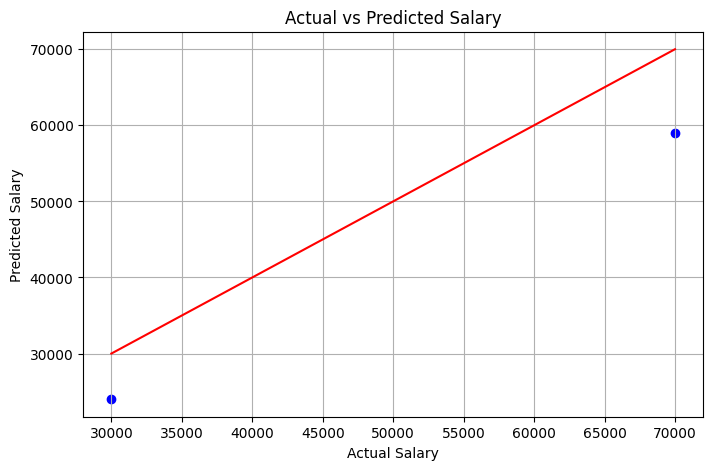

In [1017]:
# Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.grid(True)
plt.show()

In [1018]:
#mileage = [15,18,20,22,25,28]
#engine (cc) = [1000,12000,1500,1800,2000,2200]
#age = [2,3,5,4,6,7]
#price = [5L,6L,7.5L,9L,11L,13L]

In [1019]:
#Dataframe-> split-> MLR
#m-24, en - 1800, age - 5
#mae mse r2score graph actual vs predict

In [1020]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [1021]:
 # Data
data = {
    'mileage': [15, 18, 20, 22, 25, 28],
    'engine_cc': [1000, 1200, 1500, 1800, 2000, 2200],
    'age': [2, 3, 5, 4, 6, 7],
    'price': [500000, 600000, 750000, 900000, 1100000, 1300000]
}

df = pd.DataFrame(data)
print(df.head())

   mileage  engine_cc  age    price
0       15       1000    2   500000
1       18       1200    3   600000
2       20       1500    5   750000
3       22       1800    4   900000
4       25       2000    6  1100000


In [1022]:
# Features & Target
x = df.drop('price', axis=1)
y = df['price']

In [1023]:
# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=40
)

In [1024]:
# Multiple Linear Regression
model = LinearRegression()
model.fit(x_train, y_train)

print("Intercept :", model.intercept_)
print("Coefficients:", model.coef_)

Intercept : -899999.999999867
Coefficients: [140000.   -600. -50000.]


In [1025]:
# Predict on test set
y_pred = model.predict(x_test)

In [1026]:
# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print("MAE      :", mae)
print("MSE      :", mse)
print("R2 Score :", r2)

MAE      : 99999.99999998987
MSE      : 12500000000.002247
R2 Score : 0.8979591836734511


In [1027]:
# Actual vs Predicted
comparison = pd.DataFrame({
    'Actual' : y_test.values,
    'Predict': y_pred
})
print(comparison)

    Actual    Predict
0  1300000  1350000.0
1   600000   750000.0


In [1028]:
# New Prediction: mileage=24, engine=1800, age=5
new_car = [[24, 1800, 5]]
pred_price = model.predict(new_car)
print("Predicted Price for new car:", pred_price[0], "Lakhs")

Predicted Price for new car: 1129999.9999999807 Lakhs


c:\Users\MAYUR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


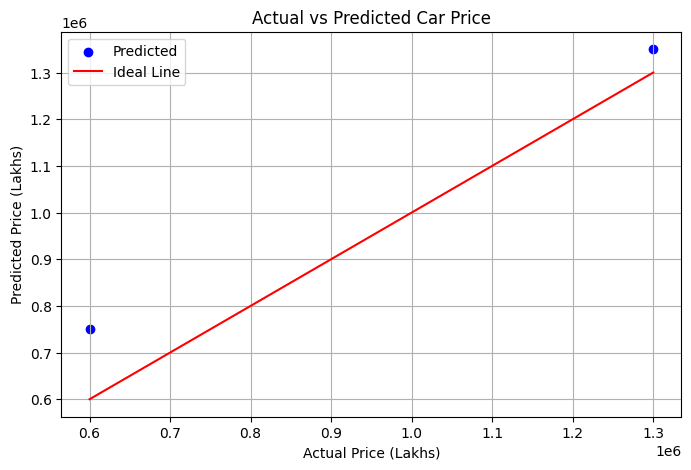

In [1029]:
# Graph
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 
         color='red', label='Ideal Line')
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted Car Price")
plt.legend()
plt.grid(True)
plt.show()